In [1]:
import os
import sys
sys.path.append('../models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from DataFetcher import DataFetcher
from MUZEstimator import MUZEstimator

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = ['Arial Unicode MS']
sns.set_palette("husl")

# 米筐 API license 从环境变量读取，使用前请设置: export RQDATAC_LICENSE='your_license_key'
license = os.environ.get('RQDATAC_LICENSE')

print("="*60)
print("MUZ 波动率估计器 - 沪深300指数")
print("="*60)


MUZ 波动率估计器 - 沪深300指数


# 1. 初始化数据获取器和MUZ估计器

我们将使用自定义的类来:
- 获取沪深300指数的高频tick数据
- 应用MUZ模型计算日度瞬时方差代理值

In [2]:
data_fetcher = DataFetcher(license=license)
data_fetcher.init_connection()

muz_estimator = MUZEstimator(data_fetcher=data_fetcher)

✓ 米筐数据连接成功


# 2. 测试单日数据处理

先用一天的数据测试tick size优化功能

In [3]:
test_date = '20250103'
symbol = '000300.XSHG'

df_test = data_fetcher.get_tick_data(symbol, test_date)
print(f"\n测试日期: {test_date}")
print(f"数据点数: {len(df_test)}")
print(f"\n价格统计:")
print(df_test['last'].describe())


测试日期: 20250103
数据点数: 1200

价格统计:
count    1200.000000
mean     3817.926271
std         8.672161
min      3798.789000
25%      3812.545125
50%      3816.865550
75%      3824.944800
max      3835.935300
Name: last, dtype: float64


In [4]:
prices_test = df_test['last']

rv_uz_test, info_test = muz_estimator.calculate_rv_uz(
    prices_test, 
    optimize_tick=True, 
    verbose=True
)

print(f"\n最终结果:")
print(f"  RV^UZ = {rv_uz_test:.8f}")
print(f"  年化波动率 ≈ {np.sqrt(rv_uz_test * 252) * 100:.2f}%")


=== Tick Size 优化结果 ===
目标 η: 0.5

候选结果:
  tick=0.005000: η=0.5366, N_alt=573, N_cont=615, 距离=0.0366
  tick=0.006000: η=0.5422, N_alt=569, N_cont=617, 距离=0.0422
  tick=0.007000: η=0.5441, N_alt=567, N_cont=617, 距离=0.0441
  tick=0.008000: η=0.5469, N_alt=565, N_cont=618, 距离=0.0469
  tick=0.009000: η=0.5480, N_alt=563, N_cont=617, 距离=0.0480
  tick=0.010000: η=0.5444, N_alt=563, N_cont=613, 距离=0.0444
  tick=0.015000: η=0.5565, N_alt=549, N_cont=611, 距离=0.0565
  tick=0.020000: η=0.5552, N_alt=543, N_cont=603, 距离=0.0552
  tick=0.025000: η=0.5549, N_alt=537, N_cont=596, 距离=0.0549
  tick=0.030000: η=0.5777, N_alt=515, N_cont=595, 距离=0.0777
  tick=3.817926: η=1.2000, N_alt=5, N_cont=12, 距离=0.7000
  tick=7.635853: η=1.0000, N_alt=2, N_cont=4, 距离=0.5000

✓ 最优 tick size: 0.005000
  对应 η: 0.5366

最终结果:
  RV^UZ = 0.00001067
  年化波动率 ≈ 5.19%


# 3. 处理多年完整数据

计算日度瞬时方差代理值

**注意**: 这会需要较长时间，建议先用较短时期测试

In [5]:
# 选项1: 测试短时期 (推荐先运行这个)
# start_date = '20250101'
# end_date = '20250131'

# # 选项2: 完整三年数据 (取消注释使用)
# start_date = '20230101'
# end_date = '20251231'

# 选项3
start_date = '20200101'
end_date = '20251231'

df_variance = muz_estimator.process_period(
    symbol='000300.XSHG',
    start_date=start_date,
    end_date=end_date,
    optimize_tick=True,
    adaptive_tick=False,  # False: 只在第一天优化tick_size; True: 每天都优化(很慢)
    verbose=True
)

print("\n结果预览:")
display(df_variance.head(10))
display(df_variance.tail(10))


开始处理 1455 个交易日的数据
标的: 000300.XSHG
时间范围: 20200101 - 20251231

进度: 1/1455 (0.1%)
✓ 首日优化完成，后续使用 tick_size = 0.020000
进度: 51/1455 (3.5%)
进度: 101/1455 (6.9%)
进度: 151/1455 (10.4%)
进度: 201/1455 (13.8%)
进度: 251/1455 (17.3%)
进度: 301/1455 (20.7%)
进度: 351/1455 (24.1%)
进度: 401/1455 (27.6%)
进度: 451/1455 (31.0%)
进度: 501/1455 (34.4%)
进度: 551/1455 (37.9%)
进度: 601/1455 (41.3%)
进度: 651/1455 (44.7%)
进度: 701/1455 (48.2%)
进度: 751/1455 (51.6%)
进度: 801/1455 (55.1%)
进度: 851/1455 (58.5%)
进度: 901/1455 (61.9%)
进度: 951/1455 (65.4%)
进度: 1001/1455 (68.8%)
进度: 1051/1455 (72.2%)
进度: 1101/1455 (75.7%)
进度: 1151/1455 (79.1%)
进度: 1201/1455 (82.5%)
进度: 1251/1455 (86.0%)
进度: 1301/1455 (89.4%)
进度: 1351/1455 (92.9%)
进度: 1401/1455 (96.3%)
进度: 1451/1455 (99.7%)
进度: 1455/1455 (100.0%)

✓ 处理完成!
  成功: 1455/1455 个交易日
  失败: 0 个交易日


结果预览:


,rv_uz,tick_size,eta,n_observations
date,,,,
2020-01-02,0.000005,0.02,0.404000,720
2020-01-03,0.000003,0.02,0.361893,720
2020-01-06,0.000006,0.02,0.368090,720
2020-01-07,0.000004,0.02,0.358586,720
2020-01-08,0.000005,0.02,0.340796,720
2020-01-09,0.000004,0.02,0.296037,720
2020-01-10,0.000005,0.02,0.366667,720
2020-01-13,0.000004,0.02,0.361461,720
2020-01-14,0.000004,0.02,0.377577,720


,rv_uz,tick_size,eta,n_observations
date,,,,
2025-12-18,0.000005,0.02,0.583810,1200
2025-12-19,0.000007,0.02,0.513369,1200
2025-12-22,0.000005,0.02,0.502679,1200
2025-12-23,0.000006,0.02,0.615842,1200
2025-12-24,0.000005,0.02,0.567308,1200
2025-12-25,0.000003,0.02,0.413997,1200
2025-12-26,0.000004,0.02,0.563688,1200
2025-12-29,0.000005,0.02,0.617234,1200
2025-12-30,0.000006,0.02,0.567797,1200


# 4. 数据可视化与统计分析

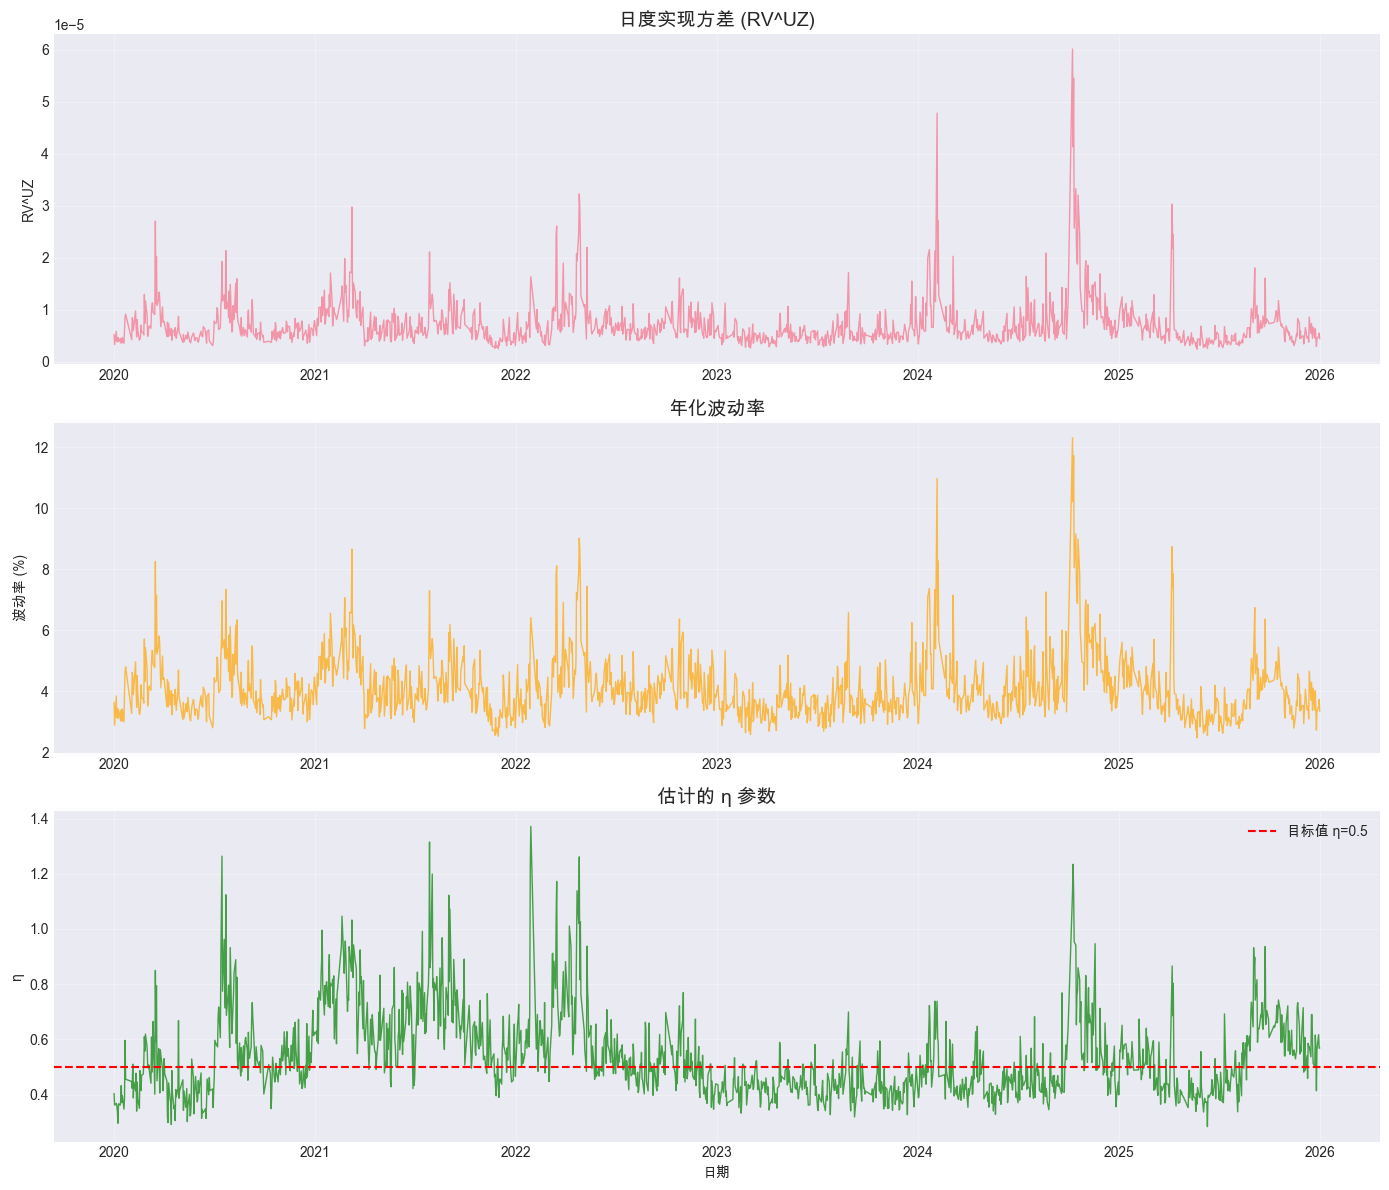

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df_variance.index, df_variance['rv_uz'], linewidth=1, alpha=0.7)
axes[0].set_title('日度实现方差 (RV^UZ)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RV^UZ')
axes[0].grid(True, alpha=0.3)

df_variance['annualized_vol'] = np.sqrt(df_variance['rv_uz'] * 252) * 100
axes[1].plot(df_variance.index, df_variance['annualized_vol'], 
             linewidth=1, alpha=0.7, color='orange')
axes[1].set_title('年化波动率', fontsize=14, fontweight='bold')
axes[1].set_ylabel('波动率 (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_variance.index, df_variance['eta'], linewidth=1, alpha=0.7, color='green')
axes[2].axhline(y=0.5, color='r', linestyle='--', label='目标值 η=0.5')
axes[2].set_title('估计的 η 参数', fontsize=14, fontweight='bold')
axes[2].set_ylabel('η')
axes[2].set_xlabel('日期')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("="*60)
print("统计摘要")
print("="*60)
print(f"\n样本量: {len(df_variance)} 个交易日")
print(f"时间范围: {df_variance.index[0].date()} 至 {df_variance.index[-1].date()}")

print(f"\n【RV^UZ 统计】")
print(f"  均值: {df_variance['rv_uz'].mean():.6f}")
print(f"  标准差: {df_variance['rv_uz'].std():.6f}")
print(f"  中位数: {df_variance['rv_uz'].median():.6f}")
print(f"  最小值: {df_variance['rv_uz'].min():.6f}")
print(f"  最大值: {df_variance['rv_uz'].max():.6f}")

print(f"\n【年化波动率统计】")
print(f"  均值: {df_variance['annualized_vol'].mean():.2f}%")
print(f"  标准差: {df_variance['annualized_vol'].std():.2f}%")
print(f"  最小值: {df_variance['annualized_vol'].min():.2f}%")
print(f"  最大值: {df_variance['annualized_vol'].max():.2f}%")

print(f"\n【η 参数统计】")
print(f"  均值: {df_variance['eta'].mean():.4f}")
print(f"  标准差: {df_variance['eta'].std():.4f}")
print(f"  与0.5的平均偏差: {abs(df_variance['eta'] - 0.5).mean():.4f}")

print(f"\n【Tick Size 统计】")
print(f"  均值: {df_variance['tick_size'].mean():.6f}")
print(f"  唯一值数: {df_variance['tick_size'].nunique()}")
if df_variance['tick_size'].nunique() == 1:
    print(f"  使用固定 tick_size: {df_variance['tick_size'].iloc[0]:.6f}")

统计摘要

样本量: 1455 个交易日
时间范围: 2020-01-02 至 2025-12-31

【RV^UZ 统计】
  均值: 0.000007
  标准差: 0.000004
  中位数: 0.000006
  最小值: 0.000002
  最大值: 0.000060

【年化波动率统计】
  均值: 4.11%
  标准差: 1.04%
  最小值: 2.48%
  最大值: 12.31%

【η 参数统计】
  均值: 0.5389
  标准差: 0.1548
  与0.5的平均偏差: 0.1139

【Tick Size 统计】
  均值: 0.020000
  唯一值数: 1
  使用固定 tick_size: 0.020000


# 5. 保存结果

将结果保存为CSV文件供后续分析使用

In [8]:
import os

output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, f'variance_proxy_{start_date}_{end_date}.csv')
df_variance.to_csv(output_file)

print(f"✓ 数据已保存至: {output_file}")
print(f"  文件大小: {os.path.getsize(output_file) / 1024:.2f} KB")

✓ 数据已保存至: ../data/variance_proxy_20200101_20251231.csv
  文件大小: 113.44 KB


# 6. 计算Hurst指数得到光滑性分析

H = 0.106, is_rough: True


<Axes: title={'center': 'Hurst 指数估计 (Variogram)\nH = 0.106, R² = 0.931'}, xlabel='log(滞后期 τ)', ylabel='log(E[|Δ|^2.0])'>

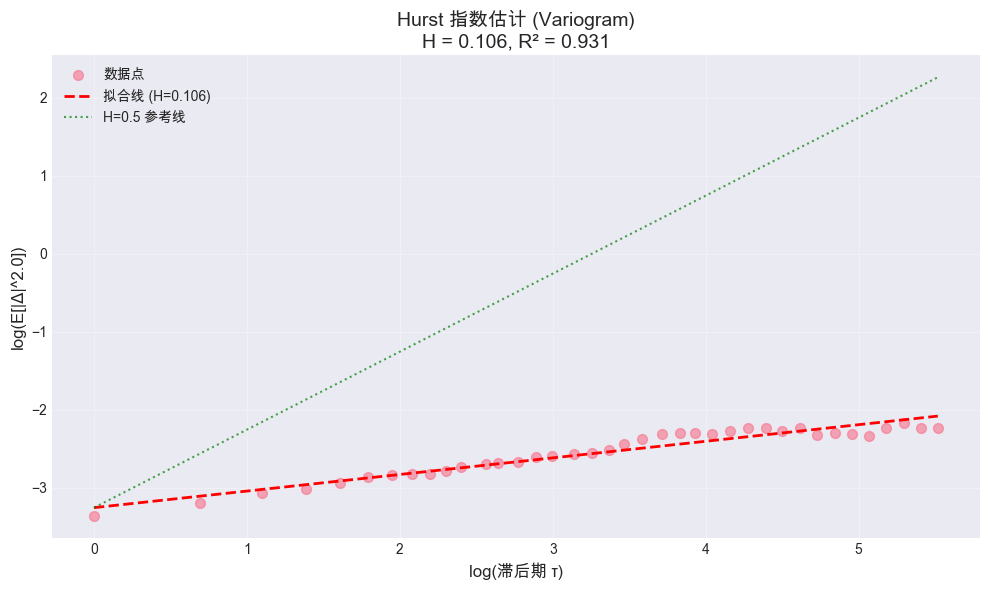

In [9]:
from HurstEstimator import HurstEstimator

hurst = HurstEstimator()

log_volatility_series = np.log(np.sqrt(df_variance['rv_uz']))

# 基础估计
H, info = hurst.estimate_hurst_variogram(log_volatility_series, q=2.0)

# 多尺度鲁棒估计
H_mean, summary = hurst.estimate_hurst_multiscale(log_volatility_series)

# Rough volatility检验
test_result = hurst.estimate_hurst_roughness_test(log_volatility_series)
print(f"H = {test_result['H']:.3f}, is_rough: {test_result['is_rough']}")

# 可视化
hurst.plot_variogram(log_volatility_series, q=2.0)

多尺度 Hurst 指数估计 - 叠加可视化

各 q 值的 Hurst 指数估计:
  q=0.5: H = 0.1106, R² = 0.9211
  q=1.0: H = 0.1095, R² = 0.9263
  q=1.5: H = 0.1081, R² = 0.9289
  q=2.0: H = 0.1064, R² = 0.9308
  q=2.5: H = 0.1044, R² = 0.9322
  q=3.0: H = 0.1021, R² = 0.9332

平均 Hurst 指数: 0.1069 ± 0.0029
✓ 波动率表现出粗糙特性 (H < 0.5)


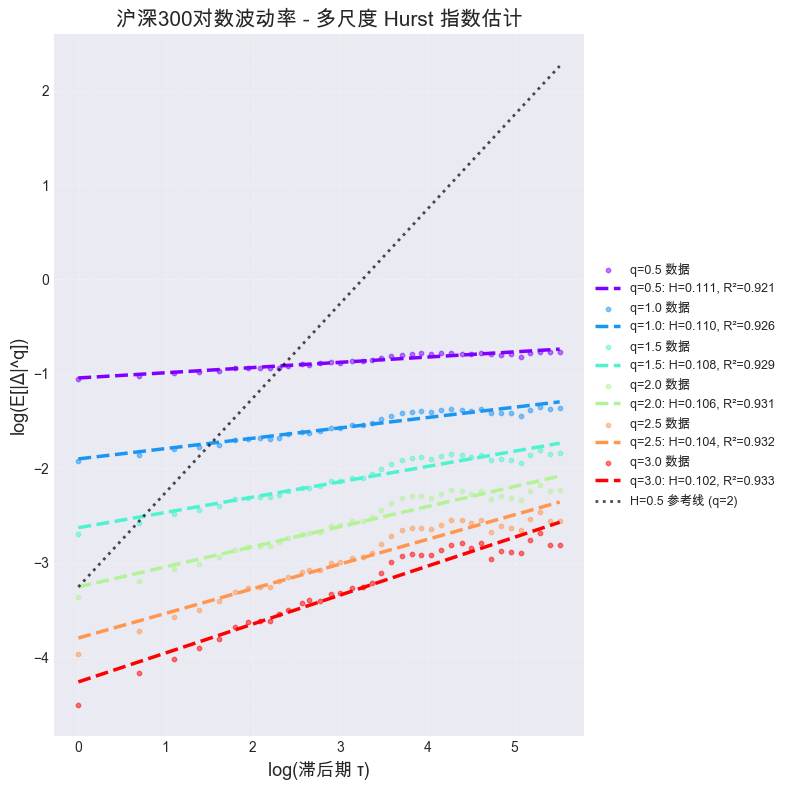

In [10]:
# 新方法演示：在同一张图上绘制多个q值的回归线
from HurstEstimator import HurstEstimator

hurst = HurstEstimator()

# 使用对数波动率
log_volatility_series = np.log(np.sqrt(df_variance['rv_uz']))

print("=" * 60)
print("多尺度 Hurst 指数估计 - 叠加可视化")
print("=" * 60)

# 定义要绘制的q值
q_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# 在同一张图上绘制所有q值的变差图和回归线
fig, ax, results = hurst.plot_multiscale_overlay(
    log_volatility_series,
    q_values=q_values,
    figsize=(8, 8),
    show_reference=True,
    title='沪深300对数波动率 - 多尺度 Hurst 指数估计'
)

# 打印每个q值的估计结果
print("\n各 q 值的 Hurst 指数估计:")
for q in q_values:
    if q in results:
        H = results[q]['H']
        r2 = results[q]['info']['r_squared']
        print(f"  q={q}: H = {H:.4f}, R² = {r2:.4f}")

# 计算平均值和标准差
H_values = [results[q]['H'] for q in q_values if q in results]
if H_values:
    H_mean = np.mean(H_values)
    H_std = np.std(H_values)
    print(f"\n平均 Hurst 指数: {H_mean:.4f} ± {H_std:.4f}")
    
    # Rough Volatility 特性判断
    if H_mean < 0.5:
        print(f"✓ 波动率表现出粗糙特性 (H < 0.5)")
    else:
        print(f"✗ 波动率不表现粗糙特性 (H >= 0.5)")

plt.show()